In [402]:
import torch   
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import os
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split, DataLoader, Dataset
from torch.amp import GradScaler
from torch.amp import autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [403]:
def normalization(x ,minimum, maximum):
    return (x - minimum) / (maximum - minimum)

def denormalization(x, minimum, maximum):
    return x * (maximum - minimum) + minimum



In [ ]:
def trouver_min_max(path_spec):
    min_val, max_val = float('inf'), float('-inf')
    count = 0

    for f in os.listdir(path_spec):
        if f.endswith('.npy'):
            data = np.load(os.path.join(path_spec, f), mmap_mode='r')  # Lecture sans tout charger en RAM
            count += 1
            min_val = min(min_val, np.min(data))
            max_val = max(max_val, np.max(data))
            
    return min_val, max_val, count

"""path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad"
min_value, max_value, num = trouver_min_max(path_spec_pad)
print(f"min_value : {min_value}")
print(f"max_value : {max_value}")
print(f"num : {num}")"""

min_value = -83.31510162353516
max_value = 43.663909912109375

Crée un masque binaire pour spectrogrammes non paddés.

Stocke dans un dict {nom_fichier: masque}

In [ ]:
def create_mask(path_non_padd):
    taillereelle = {}
    for fichier in os.listdir(path_non_padd):
        if fichier.endswith('.npy'):
            path_fichier = os.path.join(path_non_padd, fichier)
            spec = np.load(path_fichier)
            taille = spec.shape[1]
            taille_pad = np.zeros((513, 50), dtype=np.float32)
            taille_pad[:, :taille] = 1
            taillereelle[fichier] = taille_pad
    return taillereelle

masks_dict = create_mask("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad")

# Exemple d'accès :
mask_test = masks_dict["2_george_0.npy"]
print(mask_test)
mask = masks_dict


[[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]]


Ce document regroupe toutes les fonctions utiles pour charger, normaliser et masquer les spectrogrammes en DataLoaders.

In [ ]:
def list_spec_files(spec_path):
    return [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

def load_spec_normalized(file_path, minim, maxim):
    spec = np.load(file_path)
    spec_tensor = torch.from_numpy(spec).float()
    spec_norm = normalization(spec_tensor,minim,maxim)
    return spec_norm

def extract_speaker_name(file_path):
    filename = os.path.basename(file_path)
    maniere = filename.split('.npy')[0]
    return filename.split('_')[0] ,filename.split('_')[1], int(maniere.split('_')[-1])  # pour "0_nom_43.npy", donne "nom"

def load_dataset(spec_path, minim, maxim, mask):
    files = list_spec_files(spec_path)
    data = []
    for f in files:
        filename = os.path.basename(f)
        spec = load_spec_normalized(f, minim, maxim)
        nombre, speaker, maniere = extract_speaker_name(f)
        data.append((spec, mask[filename], nombre, speaker, maniere))
    return data


def get_data(spec_path, minim, maxim, mask,  split_ratio=0.8, label = None):
    dataset =load_dataset(spec_path, minim, maxim, mask)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    train_dataset = DataLoader(train_dataset, batch_size=12, shuffle=True)
    test_dataset = DataLoader(test_dataset, batch_size=12, shuffle=False)
    return train_dataset, test_dataset

path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad"
train_loader, test_loader = get_data(path_spec_pad, min_value, max_value, mask)

Mes differents modeles. Un avec que des convolutions un avec que des couches lineaires et un hybride

In [407]:
class ConvVAE2D(nn.Module):
    def __init__(self, cond=True, num_personnes=6, num_manieres=50, latent_dim=320, dim_embedding=8):
        super().__init__()
        
        self.cond = cond
        self.latent_dim = latent_dim
        self.dim_embedding = dim_embedding
        
        # Embeddings pour personne et manière
        self.embed_personne = nn.Embedding(num_personnes, dim_embedding)
        self.embed_maniere = nn.Embedding(num_manieres, dim_embedding)
        
        # Dimension de l'embedding concaténé (personne + manière)
        cond_embed_dim = 2 * dim_embedding if cond else 0
        
        # Input channels : 1 (spectrogram) + embedding_dim (si conditionnel)
        # On va projeter les embeddings vers la même résolution spatiale que l'input
        cond_input = 1 + (cond_embed_dim if cond else 0)
        
        # Projection des embeddings vers la résolution spatiale
        if cond:
            self.embed_projection = nn.Linear(cond_embed_dim, 513 * 50)  # vers la taille de l'input
        
        # ===== Encoder =====
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + (1 if cond else 0), 16, kernel_size=3, stride=2, padding=1),  # +1 channel pour les embeddings
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 65 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 65 * 7, latent_dim)
        
        # ===== Decoder =====
        self.fc_decoder = nn.Linear(latent_dim + cond_embed_dim, 64 * 65 * 7)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
        )
    
    def get_embeddings(self, personne_ids, maniere_ids):
        """Obtient les embeddings concaténés pour personne et manière"""
        if personne_ids is None or maniere_ids is None:
            return None
        
        embed_p = self.embed_personne(personne_ids)  # (batch, dim_embedding)
        embed_m = self.embed_maniere(maniere_ids)    # (batch, dim_embedding)
        
        # Concaténer les embeddings
        combined_embed = torch.cat([embed_p, embed_m], dim=1)  # (batch, 2*dim_embedding)
        return combined_embed
    
    def encode(self, x, personne_ids=None, maniere_ids=None):
        if self.cond and personne_ids is not None and maniere_ids is not None:
            # Obtenir les embeddings combinés
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            
            # Projeter vers la résolution spatiale et reshaper
            embed_spatial = self.embed_projection(combined_embed)  # (batch, 513*50)
            embed_spatial = embed_spatial.view(-1, 1, 513, 50)     # (batch, 1, 513, 50)
            
            # Concaténer avec l'input
            x = torch.cat([x, embed_spatial], dim=1)  # (batch, 2, 513, 50)
        
        x = self.encoder(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, personne_ids=None, maniere_ids=None):
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            z = torch.cat([z, combined_embed], dim=1)
        
        x = self.fc_decoder(z)
        x = x.view(-1, 64, 65, 7)
        x = self.decoder(x)
        x = F.interpolate(x, size=(513, 50), mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x, personne_ids=None, maniere_ids=None):
        mu, logvar = self.encode(x, personne_ids, maniere_ids)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, personne_ids, maniere_ids)
        return x_hat, mu, logvar
    
    def sample(self, num_samples, personne_ids=None, maniere_ids=None):
        z = torch.randn(num_samples, self.latent_dim).to(next(self.parameters()).device)
        return self.decode(z, personne_ids, maniere_ids)
    
    def reconstruct(self, x, personne_ids=None, maniere_ids=None):
        with torch.no_grad():
            mu, logvar = self.encode(x, personne_ids, maniere_ids)
            z = mu
            x_hat = self.decode(z, personne_ids, maniere_ids)
            return x_hat
    
    def transfer_speaker(self, x, personne_from, maniere_from, personne_to, maniere_to):
        """Transfer entre différentes combinaisons personne/manière"""
        with torch.no_grad():
            if x.dim() == 3:  # Si pas de batch dimension
                x = x.unsqueeze(0)
            
            # Encoder avec les conditions source
            mu, logvar = self.encode(x, personne_from, maniere_from)
            z = mu
            
            # Décoder avec les conditions cible
            out = self.decode(z, personne_to, maniere_to)
            return out
      

class CondVAEHybrid(nn.Module):
    def __init__(self, in_channels=1, cond=True, num_personnes=6, num_manieres=50, 
                 latent_dim=100, dim_embedding=8):
        super().__init__()
        self.cond = cond
        self.latent_dim = latent_dim
        self.dim_embedding = dim_embedding
        
        # Embeddings pour personne et manière
        self.embed_personne = nn.Embedding(num_personnes, dim_embedding)
        self.embed_maniere = nn.Embedding(num_manieres, dim_embedding)
        
        # Dimension de l'embedding concaténé (personne + manière)
        cond_embed_dim = 2 * dim_embedding if cond else 0
        
        # Encoder CNN simplifié pour 513x50
        self.encoder_cnn = nn.Sequential(
            # 513x50 -> 257x25
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 257x25 -> 129x13  
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 129x13 -> 65x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 65x7 -> 33x4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        
        # Calculer flatten_dim automatiquement
        self._calculate_flatten_dim()
        
        intermediate_dim = 512
        
        # Couches fully connected
        self.fc_cond = nn.Linear(self.flatten_dim + cond_embed_dim, intermediate_dim)
        self.fc_intermediate = nn.Sequential(
            nn.Linear(intermediate_dim, intermediate_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.fc_mean = nn.Linear(intermediate_dim, latent_dim)
        self.fc_logvar = nn.Linear(intermediate_dim, latent_dim)
        
        # Decoder
        self.fc_decoder = nn.Linear(latent_dim + cond_embed_dim, self.flatten_dim)
        
        self.decoder_cnn = nn.Sequential(
            # Inverse de l'encoder
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Pour normaliser la sortie
        )
        
        # Stocker les dimensions pour le reshape
        self.decoder_shape = None
        self._get_decoder_shape()
    
    def _calculate_flatten_dim(self):
        
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 513, 50)
            dummy_output = self.encoder_cnn(dummy_input)
            self.flatten_dim = dummy_output.view(1, -1).size(1)
    
    def _get_decoder_shape(self):
        
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 513, 50)
            dummy_output = self.encoder_cnn(dummy_input)
            self.decoder_shape = dummy_output.shape[1:]  # Sans la dimension batch
    
    def get_embeddings(self, personne_ids, maniere_ids):
        
        if personne_ids is None or maniere_ids is None:
            return None
        
        embed_p = self.embed_personne(personne_ids)
        embed_m = self.embed_maniere(maniere_ids)
        return torch.cat([embed_p, embed_m], dim=1)
    
    def encode(self, x, personne_ids=None, maniere_ids=None):
        # Passer par l'encoder CNN
        x = self.encoder_cnn(x)
        x = x.view(x.size(0), -1)  # Aplatir
        
        # Ajouter les embeddings conditionnels si disponibles
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            x = torch.cat([x, combined_embed], dim=1)
        
        # Passer par les couches FC
        x = F.relu(self.fc_cond(x))
        x = self.fc_intermediate(x)
        
        return self.fc_mean(x), self.fc_logvar(x)
    
    def reparameterization(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std
    
    def decode(self, z, personne_ids=None, maniere_ids=None):
        # Ajouter les embeddings conditionnels
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            z = torch.cat([z, combined_embed], dim=1)
        
        # Expansion vers les dimensions CNN
        x = self.fc_decoder(z)
        x = x.view(x.size(0), *self.decoder_shape)
        
        # Decoder CNN
        x = self.decoder_cnn(x)
        
        # Interpolation finale pour garantir les bonnes dimensions
        x = F.interpolate(x, size=(513, 50), mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x, personne_ids=None, maniere_ids=None):
        mean, logvar = self.encode(x, personne_ids, maniere_ids)
        z = self.reparameterization(mean, logvar)
        x_recon = self.decode(z, personne_ids, maniere_ids)
        return x_recon, mean, logvar
    
    def sample(self, num_samples, personne_ids=None, maniere_ids=None):
       
        z = torch.randn(num_samples, self.latent_dim).to(next(self.parameters()).device)
        return self.decode(z, personne_ids, maniere_ids)
    
    def reconstruct(self, x, personne_ids=None, maniere_ids=None):
        
        with torch.no_grad():
            if x.dim() == 3:
                x = x.unsqueeze(0).unsqueeze(1)
            
            mean, logvar = self.encode(x, personne_ids, maniere_ids)
            z = mean  # Utilise la moyenne
            x_hat = self.decode(z, personne_ids, maniere_ids)
            return x_hat
    
    def transfer_speaker(self, x, personne_from, maniere_from, personne_to, maniere_to):
        
        with torch.no_grad():
            if x.dim() == 3:
                x = x.unsqueeze(0)
            # Encoder avec les conditions source
            mean, logvar = self.encode(x, personne_from, maniere_from)
            z = mean
            
            # Décoder avec les conditions cible
            out = self.decode(z, personne_to, maniere_to)
            return out


class cond_VAE_FC(nn.Module):
    def __init__(self, layers, cond=False, num_personnes=6, num_manieres=50, 
                 latent_dim=20, dim_embedding=8, leak=.1):
        super().__init__()
        self.cond = cond
        self.layers = layers
        self.latent_dim = latent_dim
        self.dim_embedding = dim_embedding
        
        # Embeddings pour personne et manière
        self.embed_personne = nn.Embedding(num_personnes, dim_embedding)
        self.embed_maniere = nn.Embedding(num_manieres, dim_embedding)
        
        # Dimension de l'embedding concaténé (personne + manière)
        cond_embed_dim = 2 * dim_embedding if cond else 0
        
        # Encoder
        encoder = []
        if cond:
            encoder += [nn.Linear(layers[0] + cond_embed_dim, layers[1]), nn.ReLU()]
            for li, lo in zip(layers[1:-1], layers[2:]):
                encoder += [nn.Linear(li, lo), nn.ReLU()]
            self.encoder = nn.Sequential(*encoder)
        else:
            for li, lo in zip(layers[:-1], layers[1:]):
                encoder += [nn.Linear(li, lo), nn.ReLU()]
            self.encoder = nn.Sequential(*encoder)
        
        # Latent mean and variance
        self.fc_mean = nn.Linear(layers[-1], latent_dim)
        self.fc_logvar = nn.Linear(layers[-1], latent_dim)
        self.decoder_input = nn.Linear(latent_dim, layers[-1])
        
        # Decoder
        if cond:
            decoder = [nn.Linear(latent_dim + cond_embed_dim, layers[-1])]
        else:
            decoder = [nn.Linear(latent_dim, layers[-1])]
        
        rev_layers = list(reversed(layers))
        
        for li, lo in zip(rev_layers[:-2], rev_layers[1:-1]):
            decoder += [nn.Linear(li, lo), nn.ReLU()]
        decoder += [nn.Linear(layers[1], layers[0]), nn.Sigmoid()]
        self.decoder = nn.Sequential(*decoder)
    
    def get_embeddings(self, personne_ids, maniere_ids):
        
        if personne_ids is None or maniere_ids is None:
            return None
        
        embed_p = self.embed_personne(personne_ids)  # (batch, dim_embedding)
        embed_m = self.embed_maniere(maniere_ids)    # (batch, dim_embedding)
        
        # Concaténer les embeddings
        combined_embed = torch.cat([embed_p, embed_m], dim=1)  # (batch, 2*dim_embedding)
        return combined_embed
    
    def encode(self, x, personne_ids=None, maniere_ids=None):
        x = x.reshape(x.size(0), -1)
        
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            x = torch.cat([x, combined_embed], dim=1)
            x = self.encoder(x)
            mean = self.fc_mean(x)
            logvar = self.fc_logvar(x)
        else:
            x = self.encoder(x)
            mean = self.fc_mean(x)
            logvar = self.fc_logvar(x)
        
        return mean, logvar
    
    def reparameterization(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std
    
    def decode(self, x, personne_ids=None, maniere_ids=None):
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
            x = torch.cat([x, combined_embed], dim=1)
            x = self.decoder(x)
        else:
            x = self.decoder(x)
        
        return x
    
    def forward(self, x, personne_ids=None, maniere_ids=None):
        mean, logvar = self.encode(x, personne_ids, maniere_ids)
        z = self.reparameterization(mean, logvar)
        image = self.decode(z, personne_ids, maniere_ids)
        image = image.view(12, 1, 513, 50)
        return image, mean, logvar
    
    def sample(self, num_samples, personne_ids=None, maniere_ids=None):
        
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        image = self.decode(z, personne_ids, maniere_ids)
        return image
    
    def reconstruct(self, x, personne_ids=None, maniere_ids=None):
        
        with torch.no_grad():
            mean, logvar = self.encode(x, personne_ids, maniere_ids)
            z = mean
            image = self.decode(z, personne_ids, maniere_ids)
            print(image.shape)
            return image.view(image.size(0), 1, 513, 50)
    
    def transfer_speaker(self, x, personne_from, maniere_from, personne_to, maniere_to):
        
        with torch.no_grad():
            mean, logvar = self.encode(x, personne_from, maniere_from)
            z = mean 
            
            out = self.decode(z, personne_to, maniere_to)
            
            
            out = out.view(513, 50)
            
            return out
    

Ajout de la classe FiLM et d'un modele ajusté à lui

In [408]:
class FiLM(nn.Module):

    def __init__(self, hidden_dim, style_dim):
        super().__init__()
        self.gamma = nn.Linear(style_dim, hidden_dim)
        self.beta = nn.Linear(style_dim, hidden_dim)
        
        # Initialisation pour stabilité
        nn.init.ones_(self.gamma.weight)
        nn.init.zeros_(self.gamma.bias)
        nn.init.zeros_(self.beta.weight)
        nn.init.zeros_(self.beta.bias)
    
    def forward(self, hidden, style):
        gamma = self.gamma(style)
        beta = self.beta(style)
        
        # Clamp gamma pour éviter des valeurs extrêmes
        gamma = torch.clamp(gamma, min=0.1, max=10.0)
        
        # Reshape pour broadcasting
        gamma = gamma.unsqueeze(2).unsqueeze(3)
        beta = beta.unsqueeze(2).unsqueeze(3)
        
        return hidden * gamma + beta

In [409]:
class ConvVAE2D_film(nn.Module):
    def __init__(self, cond=True, num_personnes=6, num_manieres=50, latent_dim=320, dim_embedding=8):
        super().__init__()
        
        self.cond = cond
        self.latent_dim = latent_dim
        self.dim_embedding = dim_embedding
        
        # Embeddings avec initialisation normale
        self.embed_personne = nn.Embedding(num_personnes, dim_embedding)
        self.embed_maniere = nn.Embedding(num_manieres, dim_embedding)
        
        # Initialisation des embeddings
        nn.init.normal_(self.embed_personne.weight, 0, 0.1)
        nn.init.normal_(self.embed_maniere.weight, 0, 0.1)
        
        cond_embed_dim = 2 * dim_embedding if cond else 0
        
        # Encoder
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        
        # Batch norm pour stabilité
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)
        
        if cond:
            self.film1 = FiLM(16, cond_embed_dim)
            self.film2 = FiLM(32, cond_embed_dim)
            self.film3 = FiLM(64, cond_embed_dim)
        
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 65 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 65 * 7, latent_dim)
        
        # Decoder
        self.fc_decoder = nn.Linear(latent_dim, 64 * 65 * 7)
        
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1)
        
        # Batch norm pour le decoder
        self.bn_dec1 = nn.BatchNorm2d(32)
        self.bn_dec2 = nn.BatchNorm2d(16)
        
        if cond:
            self.film_dec1 = FiLM(32, cond_embed_dim)
            self.film_dec2 = FiLM(16, cond_embed_dim)
    
    def get_embeddings(self, personne_ids, maniere_ids):
        if personne_ids is None or maniere_ids is None:
            return None
        
        embed_p = self.embed_personne(personne_ids)
        embed_m = self.embed_maniere(maniere_ids)
        combined_embed = torch.cat([embed_p, embed_m], dim=1)
        return combined_embed
    
    def encode(self, x, personne_ids=None, maniere_ids=None):
        combined_embed = None
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
        
        # Encoder avec batch norm et FiLM
        x = F.relu(self.bn1(self.conv1(x)))
        if self.cond and combined_embed is not None:
            x = self.film1(x, combined_embed)
        
        x = F.relu(self.bn2(self.conv2(x)))
        if self.cond and combined_embed is not None:
            x = self.film2(x, combined_embed)
        
        x = F.relu(self.bn3(self.conv3(x)))
        if self.cond and combined_embed is not None:
            x = self.film3(x, combined_embed)
        
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        # Clamp pour éviter les explosions
        logvar = torch.clamp(logvar, min=-10, max=10)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, personne_ids=None, maniere_ids=None):
        combined_embed = None
        if self.cond and personne_ids is not None and maniere_ids is not None:
            combined_embed = self.get_embeddings(personne_ids, maniere_ids)
        
        x = self.fc_decoder(z)
        x = x.view(-1, 64, 65, 7)
        
        # Decoder avec batch norm et FiLM
        x = F.relu(self.bn_dec1(self.deconv1(x)))
        if self.cond and combined_embed is not None:
            x = self.film_dec1(x, combined_embed)
        
        x = F.relu(self.bn_dec2(self.deconv2(x)))
        if self.cond and combined_embed is not None:
            x = self.film_dec2(x, combined_embed)
        
        x = torch.sigmoid(self.deconv3(x))  # Sigmoid pour borner la sortie
        x = F.interpolate(x, size=(513, 50), mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x, personne_ids=None, maniere_ids=None):
        mu, logvar = self.encode(x, personne_ids, maniere_ids)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, personne_ids, maniere_ids)
        return x_hat, mu, logvar
    
    def sample(self, num_samples, personne_ids=None, maniere_ids=None):
        z = torch.randn(num_samples, self.latent_dim).to(next(self.parameters()).device)
        return self.decode(z, personne_ids, maniere_ids)
    
    def reconstruct(self, x, personne_ids=None, maniere_ids=None):
        with torch.no_grad():
            mu, logvar = self.encode(x, personne_ids, maniere_ids)
            z = mu
            x_hat = self.decode(z, personne_ids, maniere_ids)
            return x_hat
    
    def transfer_speaker(self, x, personne_from, maniere_from, personne_to, maniere_to):
        with torch.no_grad():
            if x.dim() == 3:
                x = x.unsqueeze(0)
            
            mu, logvar = self.encode(x, personne_from, maniere_from)
            z = self.reparameterize(mu, logvar)
            out = self.decode(z, personne_to, maniere_to)
            return out


afficher loss mixte est pour afficher durant l'entrainement

In [ ]:
def afficher_losses_mixte(path, train_losses, test_losses, epoch, offset=3):

    os.makedirs(path, exist_ok=True)

    # Définir les abscisses pour chaque série
    x_train = list(range(offset, offset + len(train_losses)))
    x_test  = list(range(offset, offset + len(test_losses)))

    plt.figure(figsize=(8, 4))
    plt.plot(x_train, train_losses,   marker='o', label='Train Loss', linewidth=2)
    plt.plot(x_test,  test_losses,    marker='s', label='Test Loss',  linewidth=2)

    plt.title(f'Loss Train vs Test (epoch {epoch})', fontsize=14, weight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss',  fontsize=12)
    plt.grid(linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)

    # Annoter dernier point de chaque courbe
    if train_losses:
        xt, yt = x_train[-1], train_losses[-1]
        plt.scatter([xt], [yt], zorder=3)
        plt.annotate(f'{yt:.2f}', xy=(xt, yt),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center')
    if test_losses:
        xv, yv = x_test[-1], test_losses[-1]
        plt.scatter([xv], [yv], zorder=3)
        plt.annotate(f'{yv:.2f}', xy=(xv, yv),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center')

    plt.tight_layout()
    save_path = os.path.join(path, f"loss_mixte_epoch_{epoch}.png")
    plt.savefig(save_path)
    plt.close()
    print(f"loss sauvé {save_path}")

In [ ]:
def cond_train_model_vae(data_loader, model, criterion, optimizer, nepochs,  personne_to_id, scheduler = None):
    #List to store loss to visualize
    path1 = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P4\\affichage\\train"
    loss_tot = []
    loss_test= []
    for epoch in range(0, nepochs):
        train_loss = 0.
        model.train()
        
        for batch_idx, (input_,mask ,nombre ,personne, maniere) in enumerate(tqdm(data_loader, desc="Batch", leave=False)):         
            input_ = input_.unsqueeze(1).to(device)
            mask = mask.unsqueeze(1).to(device)
            maniere_ids = maniere.to(device)
            personne_ids = torch.tensor([personne_to_id[p] for p in personne]).to(device)
            
            
            optimizer.zero_grad()
            output, mean, logvar = model(input_, personne_ids, maniere_ids)
            loss = criterion(output,input_, mean, logvar, mask=mask)
            
            loss.backward()
            optimizer.step()
            
            # update training loss
            train_loss += loss.item()
        loss_tot.append(train_loss)
        
        if scheduler is not None:
            scheduler.step(train_loss)
            
        print('Epoch: {} \tTraining Loss: {:.6f}'.format(
            epoch, train_loss))
       
        if epoch % 1 == 0 and epoch != 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, (input_,mask ,nombre ,personne, maniere) in enumerate(tqdm(data_loader, desc="Batch", leave=False)):         
                    input_ = input_.unsqueeze(1).to(device)
                    mask = mask.unsqueeze(1).to(device)
                    maniere_ids = maniere.to(device)
                    personne_ids = torch.tensor([personne_to_id[p] for p in personne]).to(device)
                    
                    
                    output, mean, logvar = model(input_, personne_ids, maniere_ids)
                    loss = criterion(output,input_, mean, logvar, mask=mask)
                    test_loss += loss.item()
                    # update training loss
            loss_test.append(test_loss)
        
        if epoch % 10 == 0 and epoch != 0:
            
            afficher_losses_mixte(
                path=path1, 
                train_losses=loss_tot[3:], 
                test_losses=loss_test[3:], 
                epoch=epoch,
                offset=3
            )
            
            
            
            

Mes fonctions de loss 

In [412]:
def vae_loss_function(recon_x, x, mu, logvar, mask):
    if mask is None:
        mask = torch.ones_like(x)
   
    masked_recon_x = recon_x * mask
    masked_x = x * mask

    
    recon_loss = F.mse_loss(masked_recon_x, masked_x, reduction='sum') / mask.sum()

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    B=0.1
    return recon_loss + B*kl_loss

def vae_loss_log1p(x_hat, x, mu, logvar, mask=None, beta=0.1):
    
    if mask is None:
        mask = torch.ones_like(x_log)
        
    x_log = torch.log1p(x)
    x_hat_log = torch.log1p(x_hat)
    
    x_log = x_log * mask
    x_hat_log = x_hat_log * mask

   
    recon_loss = F.l1_loss(x_hat_log, x_log, reduction='sum') / mask.sum()

   
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss

def vae_loss_log1p_2(x_hat, x, mu, logvar, mask = None, beta=0.01):
    if mask is None:
        mask = torch.ones_like(x_log)
   
    x_log = torch.log1p(x)
    x_hat_log = torch.log1p(x_hat)

   
    recon_error = F.l1_loss(x_hat_log, x_log, reduction='none') * mask

   
    recon_loss_per_sample = recon_error.sum(dim=[1, 2, 3]) / mask.sum(dim=[1, 2, 3]).clamp(min=1)
    recon_loss = recon_loss_per_sample.mean()

    
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.shape[0]

    return recon_loss + beta * kl_loss

def perceptual_vae_loss(x_hat, x, mu, logvar, mask, beta=0.2):
    
    x_norm = torch.log1p((100 * x).clamp(min=0))
    x_hat_norm = torch.log1p((100 * x_hat).clamp(min=0))

   
    freq_weights = 1 + torch.linspace(0, 2, x.shape[-2]).to(x.device)

    
    recon_loss = (freq_weights[None, None, :, None] *
                  (x_hat_norm - x_norm).abs() *
                  mask)

    recon_loss = recon_loss.sum() / mask.sum().clamp(min=1)

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)

    return recon_loss + beta * kl_loss


Une loss adapté au modele FiLM car beaucoup d'instabilité

In [413]:
def vae_loss_log1p_fixed(x_hat, x, mu, logvar, mask=None, beta=0.1):
    
    x = torch.clamp(x, min=0.0)
    x_hat = torch.clamp(x_hat, min=0.0)
    
    x_log = torch.log1p(x)
    x_hat_log = torch.log1p(x_hat)
    
    if mask is None:
        mask = torch.ones_like(x_log)
    
    mask_sum = mask.sum()
    if mask_sum == 0:
        mask_sum = 1.0  # Éviter division par 0
    
    x_log_masked = x_log * mask
    x_hat_log_masked = x_hat_log * mask
    
    recon_loss = F.l1_loss(x_hat_log_masked, x_log_masked, reduction='sum') / mask_sum
    
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    if torch.isnan(recon_loss) or torch.isinf(recon_loss):
        print(f"NaN/Inf dans recon_loss: {recon_loss}")
        recon_loss = torch.tensor(0.0, device=x.device)
    
    if torch.isnan(kl_loss) or torch.isinf(kl_loss):
        print(f"NaN/Inf dans kl_loss: {kl_loss}")
        kl_loss = torch.tensor(0.0, device=x.device)
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss

In [414]:
personne_to_id = {'lucas':1, 'theo':2, 'george':3, 'jackson':4, 'nicolas':5, 'yweweler':0}

In [415]:
# model
input_dim = 513 * 50  # = 92250
embedding_dim = 20

model_fc = cond_VAE_FC(
    layers=[input_dim, 500, 100],  # taille correcte
    cond=True,
    latent_dim=32, dim_embedding = embedding_dim
).to(device)

model_convo = ConvVAE2D(latent_dim= 30, dim_embedding = embedding_dim).to(device)
model_hybride = CondVAEHybrid(latent_dim = 50, dim_embedding = embedding_dim).to(device)
model_film = ConvVAE2D_film(cond=True).to(device)


model = model_convo

# loss function

criterion = vae_loss_log1p

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

nepochs = 41

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)


cond_train_model_vae(train_loader, model, criterion, optimizer, nepochs, personne_to_id, scheduler)

torch.save(model.state_dict(), "mon_vae_fc.pt")




Epoch: 0 	Training Loss: 21.332815


Epoch: 1 	Training Loss: 6.862937


Epoch: 2 	Training Loss: 6.669159


Epoch: 3 	Training Loss: 6.592864


Epoch: 4 	Training Loss: 6.514117


...

Epoch: 37 	Training Loss: 6.170305


Epoch: 38 	Training Loss: 6.171560


Epoch: 39 	Training Loss: 6.155513


Epoch: 40 	Training Loss: 6.166145


Saved mixed loss plot to C:\Users\gabri\Desktop\dauphine\L3\S2\Deep_learning\nouveau_projet\finalp2\affichage\train\loss_mixte_epoch_40.png


Dans la suite il va y avoir différentes reconstructions / changements de style et une representation de l'embedding

In [416]:
def afficher_image(output,fichier):
    plt.figure(figsize=(10, 4))
    plt.imshow(output, aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(label='Amplitude (denormalisée)')
    plt.title(f"Spectrogramme : {fichier}")
    plt.xlabel("Temps (frames)")
    plt.ylabel("Fréquences (bins)")
    plt.tight_layout()
    plt.show()
    
def afficher_audio(spec):
    
    S = librosa.db_to_amplitude(spec)

    # 3. Reconstruction du signal audio via Griffin-Lim
    audio = librosa.griffinlim(S, hop_length=512, n_fft=1024)
    audio= librosa.effects.time_stretch(audio, rate=0.50)
    # 4. Lecture
    return ipd.Audio(audio, rate=22050)
    

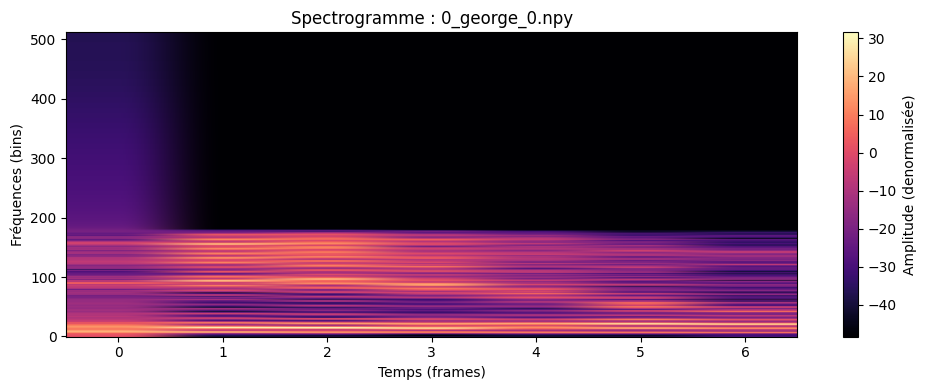

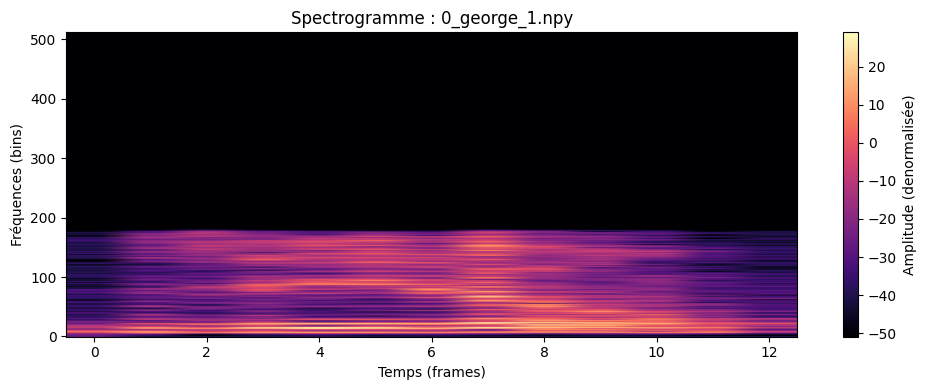

In [ ]:
i=0
path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad"
for fichier in os.listdir(path_spec_pad):
        if fichier.endswith('.npy'):
            # Charger le spectrogramme
            spec_path = os.path.join(path_spec_pad, fichier)
            spec = np.load(spec_path)
            vrai_taille = int(mask[fichier][0].sum())
            spec = spec[:, :vrai_taille]
            afficher_image(spec,fichier)
            audio = afficher_audio(spec)
            display(audio)
            

            i+=1
            if i==2:
                break

Output shape: torch.Size([1, 1, 513, 50])


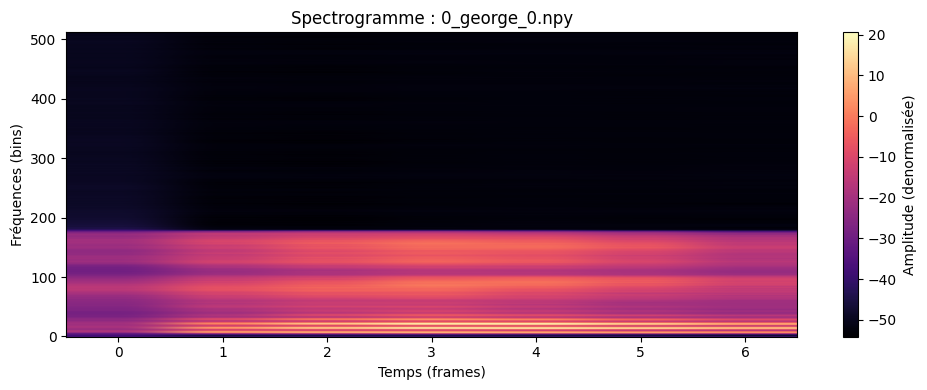

In [ ]:
def reconstruction_test():
    """Test de reconstruction avec embeddings"""
    path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad"
    
    for fichier in os.listdir(path_spec_pad):
        if fichier.endswith('.npy'):
            # Charger le spectrogramme
            spec_path = os.path.join(path_spec_pad, fichier)
            spec = np.load(spec_path)
            spec = spec.astype(np.float32)
            spec = torch.from_numpy(spec).to(device)
            spec = spec.unsqueeze(0).unsqueeze(1)  # (1, 1, H, W)
            
            # Extraire le nom de la personne et convertir en ID
            personne_nom = fichier.split("_")[1]
            personne_id = torch.tensor([personne_to_id[personne_nom]]).to(device)
            # Pour la manière, il faut l'extraire du fichier ou utiliser une valeur par défaut
            # Si la manière est dans le nom de fichier, sinon mettre 0 par défaut
            try:
                maniere_id = torch.tensor([int(fichier.split("_")[2])]).to(device)  # Si manière dans le nom
            except:
                maniere_id = torch.tensor([0]).to(device)  # Valeur par défaut
            
            model.eval()
            output = model.reconstruct(spec, personne_id, maniere_id)
            print(f"Output shape: {output.shape}")
            
            output = output.squeeze().squeeze().detach().cpu().numpy()
            vrai_taille = int(mask[fichier][0].sum())
            output = output[:, :vrai_taille]
            output = denormalization(output, min_value, max_value)
            
            afficher_image(output, fichier)
            audio = afficher_audio(output)
            display(audio)
            break
        
reconstruction_test()

Output shape: torch.Size([1, 1, 513, 50])


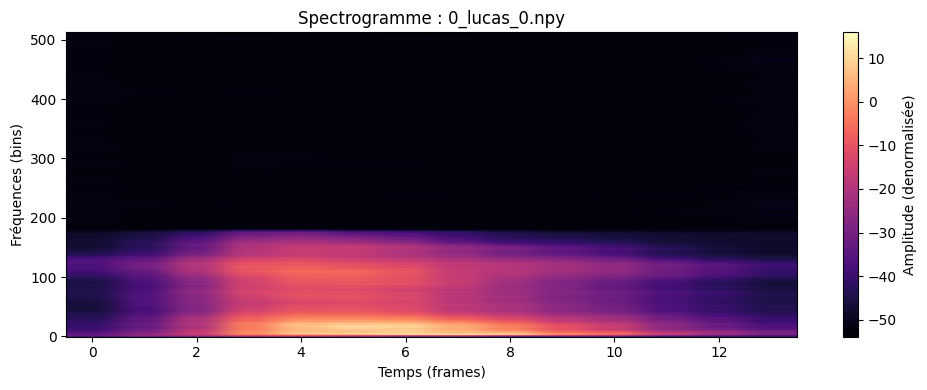

In [ ]:
def reconstruction_test():
    """Test de reconstruction avec embeddings"""
    path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_pad"
    
    for fichier in os.listdir(path_spec_pad):
        if fichier.endswith('.npy'):
            # Charger le spectrogramme
            spec_path = os.path.join(path_spec_pad, fichier)
            spec = np.load(spec_path)
            spec = spec.astype(np.float32)
            spec = torch.from_numpy(spec).to(device)
            spec = spec.unsqueeze(0).unsqueeze(1)  # (1, 1, H, W)
            
            # Extraire le nom de la personne et convertir en ID
            personne_nom = fichier.split("_")[1]
            if personne_nom == "lucas":
                personne_id = torch.tensor([personne_to_id[personne_nom]]).to(device)
                # Pour la manière, il faut l'extraire du fichier ou utiliser une valeur par défaut
                # Si la manière est dans le nom de fichier, sinon mettre 0 par défaut
                try:
                    maniere_id = torch.tensor([int(fichier.split("_")[2])]).to(device)  # Si manière dans le nom
                except:
                    maniere_id = torch.tensor([0]).to(device)  # Valeur par défaut
                
                model.eval()
                output = model.reconstruct(spec, personne_id, maniere_id)
                print(f"Output shape: {output.shape}")
                
                output = output.squeeze().squeeze().detach().cpu().numpy()
                vrai_taille = int(mask[fichier][0].sum())
                output = output[:, :vrai_taille]
                output = denormalization(output, min_value, max_value)
                
                afficher_image(output, fichier)
                audio = afficher_audio(output)
                display(audio)
                break
        
reconstruction_test()

Transfer: lucas (ID: 1) -> george (ID: 3)
Manière: 0 -> 0
Fichier : C:\Users\gabri\Desktop\dauphine\L3\S2\Deep_learning\nouveau_projet\finalp2\spec_pad\0_lucas_0.npy
From: personne=lucas(1), maniere=0
To: personne=george(3), maniere=0
torch.Size([1, 513, 50])
Changement shape: torch.Size([1, 1, 513, 50])


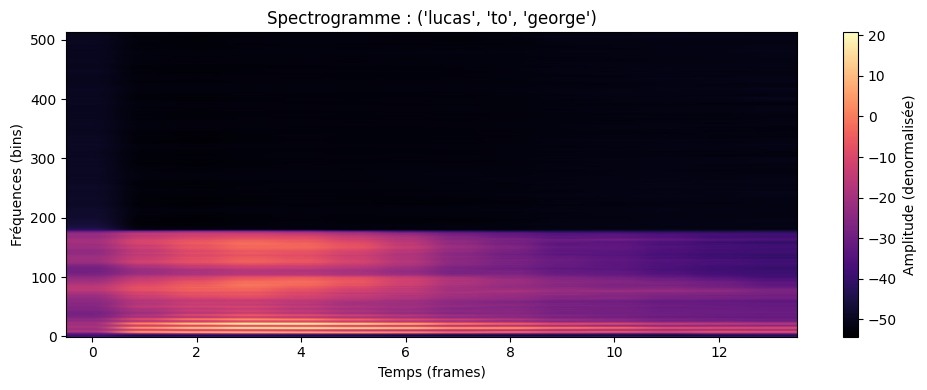

In [420]:
def changement_de_personne(model, path_spec, a_name, b_name, maniere_source=0, maniere_target=0):
    """
    Changement de personne avec embeddings
    
    Args:
        path_spec: Chemin vers les spectrogrammes
        a_name: Nom de la personne source (string)
        b_name: Nom de la personne cible (string)
        maniere_source: ID de la manière source (int)
        maniere_target: ID de la manière cible (int)
    """
    # Convertir les noms en IDs
    a_id = personne_to_id[a_name]
    b_id = personne_to_id[b_name]
    
    print(f"Transfer: {a_name} (ID: {a_id}) -> {b_name} (ID: {b_id})")
    print(f"Manière: {maniere_source} -> {maniere_target}")
    
    for fichier in os.listdir(path_spec):
        if fichier.endswith('.npy'):
            file_path = os.path.join(path_spec, fichier)
            
            # Extraire le nom de la personne du fichier
            nom = fichier.split("_")[-2]  # ou [1] selon votre format
            maniere = fichier.split(".npy")[0].split("_")[-1]

            if nom == a_name and int(maniere) == maniere_source:
                data = np.load(file_path)
                print("Fichier :", file_path)
                
                spec = torch.from_numpy(data).float()
                spec = (spec - min_value) / (max_value - min_value)
                x = spec.unsqueeze(0).to(device).contiguous()  # (1, H, W)
                
                # Créer les tenseurs d'IDs
                personne_from = torch.tensor([a_id]).to(device)
                maniere_from = torch.tensor([maniere_source]).to(device)
                personne_to = torch.tensor([b_id]).to(device)
                maniere_to = torch.tensor([maniere_target]).to(device)
                
                print(f"From: personne={a_name}({a_id}), maniere={maniere_source}")
                print(f"To: personne={b_name}({b_id}), maniere={maniere_target}")
                print(x.shape)
                # Transfer avec la nouvelle signature
                changement = model.transfer_speaker(x, personne_from, maniere_from, 
                                                  personne_to, maniere_to)
                print(f"Changement shape: {changement.shape}")
                
                changement = changement.squeeze().squeeze().detach().cpu().numpy()
                vrai_taille = int(mask[fichier][0].sum())
                changement = changement[:, :vrai_taille]
                changement = denormalization(changement, min_value, max_value)
                
                afficher_image(changement, (a_name, "to", b_name))
                audio = afficher_audio(changement)
                display(audio)

                break


                
changement_de_personne(model, path_spec_pad, "lucas", "george")




george lucas 0 0

=== Transfer: george -> lucas (manière 0 -> 0) ===
Transfer: george (ID: 3) -> lucas (ID: 1)
Manière: 0 -> 0
Fichier : C:\Users\gabri\Desktop\dauphine\L3\S2\Deep_learning\nouveau_projet\finalp2\spec_pad\0_george_0.npy
From: personne=george(3), maniere=0
To: personne=lucas(1), maniere=0
torch.Size([1, 513, 50])
Changement shape: torch.Size([1, 1, 513, 50])


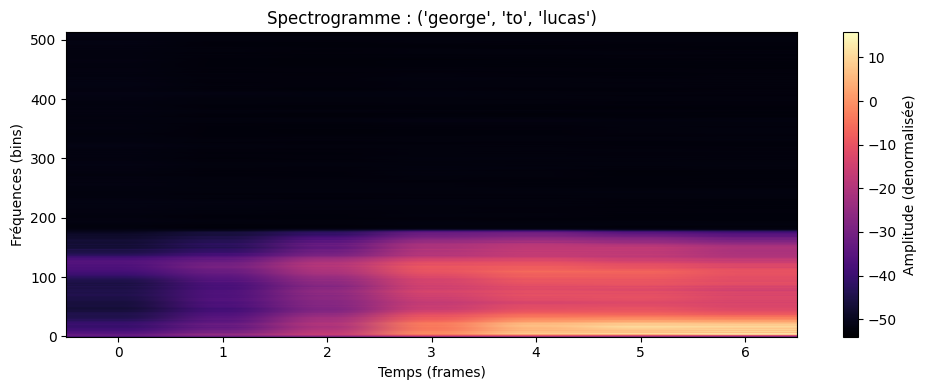

lucas nicolas 2 2

=== Transfer: lucas -> nicolas (manière 2 -> 2) ===
Transfer: lucas (ID: 1) -> nicolas (ID: 5)
Manière: 2 -> 2
Fichier : C:\Users\gabri\Desktop\dauphine\L3\S2\Deep_learning\nouveau_projet\finalp2\spec_pad\0_lucas_2.npy
From: personne=lucas(1), maniere=2
To: personne=nicolas(5), maniere=2
torch.Size([1, 513, 50])
Changement shape: torch.Size([1, 1, 513, 50])


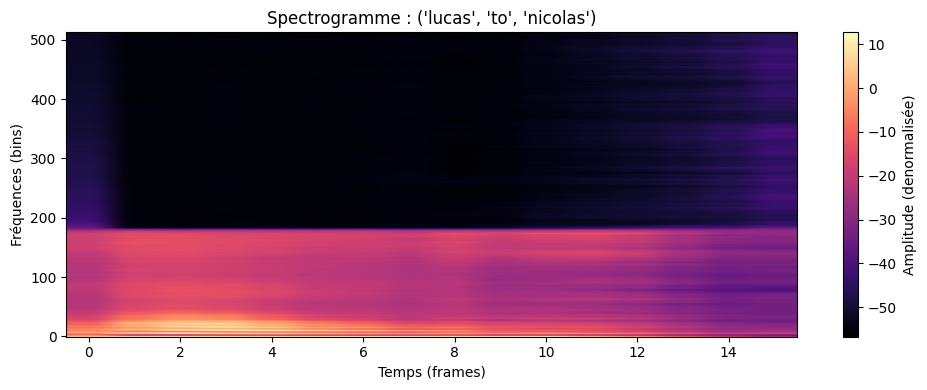

jackson yweweler 1 2

=== Transfer: jackson -> yweweler (manière 1 -> 2) ===
Transfer: jackson (ID: 4) -> yweweler (ID: 0)
Manière: 1 -> 2
Fichier : C:\Users\gabri\Desktop\dauphine\L3\S2\Deep_learning\nouveau_projet\finalp2\spec_pad\0_jackson_1.npy
From: personne=jackson(4), maniere=1
To: personne=yweweler(0), maniere=2
torch.Size([1, 513, 50])
Changement shape: torch.Size([1, 1, 513, 50])


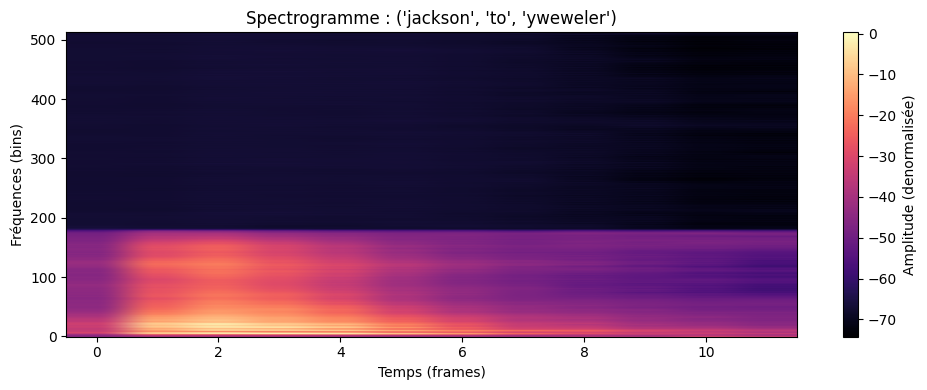

In [425]:
def changement_de_personne_avance(model, path_spec, transferts):
    """
    Exemple:
        transferts = [
            ("lucas", "george", 0, 0),      # Même manière
            ("lucas", "george", 0, 5),      # Changement de manière aussi
            ("theo", "nicolas", 2, 3),      # Autre combinaison
        ]
    """
    for a_name, b_name, maniere_source, maniere_target in transferts:
        print(a_name, b_name, maniere_source, maniere_target)
        print(f"\n=== Transfer: {a_name} -> {b_name} (manière {maniere_source} -> {maniere_target}) ===")
        changement_de_personne(model, path_spec, a_name, b_name, maniere_source, maniere_target)



transferts = [
     ("george", "lucas", 0, 0),
     ("lucas", "nicolas", 2, 2),
     ("jackson", "yweweler", 1, 2),
 ]
changement_de_personne_avance(model, path_spec_pad, transferts)


In [ ]:
def analyse_embeddings():
    model.eval()
    
    print("\n=== Distances entre personnes ===")
    noms = list(personne_to_id.keys())
    for i, nom1 in enumerate(noms):
        for j, nom2 in enumerate(noms[i+1:], i+1):
            embed1 = model.embed_personne(torch.tensor([personne_to_id[nom1]]).to(device))
            embed2 = model.embed_personne(torch.tensor([personne_to_id[nom2]]).to(device))
            distance = torch.norm(embed1 - embed2).item()
            print(f"{nom1} <-> {nom2}: {distance:.3f}")

# Analyser les embeddings appris
analyse_embeddings()


#faire beau plot


=== Distances entre personnes ===
lucas <-> theo: 6.352
lucas <-> george: 6.470
lucas <-> jackson: 6.744
lucas <-> nicolas: 7.939
lucas <-> yweweler: 5.752
theo <-> george: 6.408
theo <-> jackson: 5.736
theo <-> nicolas: 6.661
theo <-> yweweler: 5.951
george <-> jackson: 5.864
george <-> nicolas: 6.632
george <-> yweweler: 6.448
jackson <-> nicolas: 5.994
jackson <-> yweweler: 5.511
nicolas <-> yweweler: 7.108


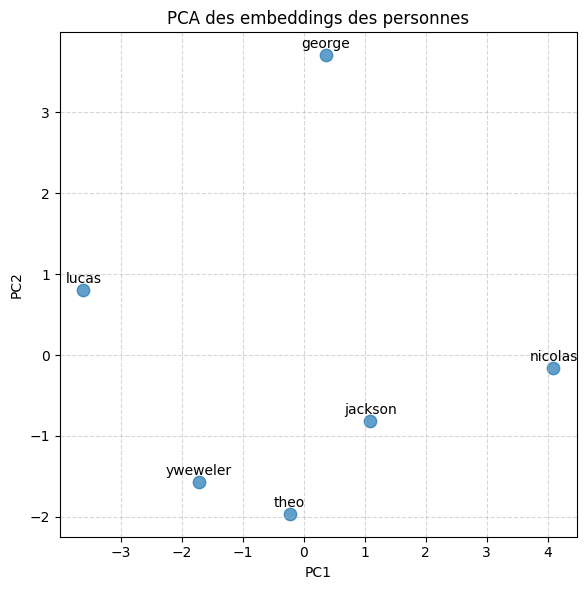

In [423]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_person_embeddings(model, personne_to_id, device):

    model.eval()
    names = list(personne_to_id.keys())
    # Récupérer et convertir les embeddings
    embs = []
    for name in names:
        idx = torch.tensor([personne_to_id[name]], device=device)
        emb = model.embed_personne(idx).detach().cpu().numpy().squeeze()
        embs.append(emb)
    embs = np.stack(embs)  # shape (num_personnes, dim_embedding)

    # PCA → 2D
    pca = PCA(n_components=2)
    emb2d = pca.fit_transform(embs)

    # Trace
    plt.figure(figsize=(6,6))
    plt.scatter(emb2d[:,0], emb2d[:,1], s=80, alpha=0.7)
    for i, name in enumerate(names):
        plt.annotate(name,
                     (emb2d[i,0], emb2d[i,1]),
                     textcoords="offset points",
                     xytext=(0,5), ha='center')
    plt.title("PCA des embeddings des personnes")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
plot_person_embeddings(model, personne_to_id, device)
